In [1]:
import numpy as np
from brian2 import *
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # 3D plotting

In [2]:
plt.rcParams.update({
    'font.size': 18,          # Controls default text size
    'axes.titlesize': 18,     # Title font size
    'axes.labelsize': 18,     # X/Y label font size
    'xtick.labelsize': 16,    # X tick labels
    'ytick.labelsize': 16,    # Y tick labels
    'legend.fontsize': 14,    # Legend font size
})

### Run the simulation

In [3]:
# Define simulation time parameters
dtime = 0.1 * ms
duration = 26000 * ms
start_scope()
defaultclock.dt = dtime

# ----- Parameters -----
parameters = {'C':200, 'gL':10, 'EL':-65, 'V_T':-55, 'V_reset':-58, 'V_spike':-20, 'tau_w':20, 'a':4, 'b':60}
    
# Dimensional parameters for Brian2 simulation
C = parameters.get('C') * pF                # Capacitance
g_L = parameters.get('gL') * nS/mV          # Leak conductance
E_L = parameters.get('EL') * mV             # Resting potential
V_T = parameters.get('V_T') * mV            # Threshold potential
tau_w = parameters.get('tau_w') * ms        # Adaptation time constant
a = parameters.get('a') * nS                # Subthreshold adaptation
b = parameters.get('b') * pA                # Spike-triggered adaptation
V_reset = parameters.get('V_reset') * mV    # Reset potential
V_spike = parameters.get('V_spike') * mV    # Spike potential
# Time-varying external current
AmpStep = 5
BaseI = 20
time_steps = int(duration / dtime)  # Total number of time steps
current_array = np.full(time_steps, BaseI)  # Start with base current (e.g., 80 pA)

step_duration = int(200 * ms / dtime)  # Number of steps per 200 ms
half_steps = time_steps // (2 * step_duration)  # Number of increasing (and decreasing) steps

# Increase phase
for i in range(half_steps):
    start = i * step_duration
    end = start + step_duration
    current_array[start:end] = BaseI + AmpStep * (i + 1)

# Decrease phase
for i in range(half_steps):
    start = (half_steps + i) * step_duration
    end = start + step_duration
    current_array[start:end] = BaseI + AmpStep * (half_steps - i - 1)

# Create TimedArray
I_t = TimedArray(current_array * pA, dt=dtime)  # Keep units in pA

In [ ]:
# Model equations
eqs = '''
dV/dt = (g_L * (E_L - V) * (V_T - V) + w + I_ext) / C : volt
dw/dt = (a * (V - E_L) - w) / tau_w : amp
I_ext = I_t(t) : amp
'''

# Define neuron group
G = NeuronGroup(1, eqs, threshold='V > V_spike', reset='V = V_reset; w += b', method='rk4')
G.V = E_L  # Initial membrane potential
G.w = 0 * pA  # Initial adaptation current

# Monitor variables
M_spike = SpikeMonitor(G)
M_FR = PopulationRateMonitor(G)
M_var = StateMonitor(G, ['V', 'w'], record=True)
spikemon = SpikeMonitor(G)

# Run simulation and save results
run(duration)

current_array = I_t.values / pA  # Convert back to pA for plotting
VarV = M_var.V[0] / mV  # Convert to mV for plotting
Varw = M_var.w[0] / pA  # Convert to pA for plotting

# Clip VarV values above -30 mV to -20 mV for better visualization
VarV[VarV > -30] = -20

In [ ]:
# Compute the equilibrium points (roots) for the given range of I_ext values
# Constants (unitless, from Brian2 parameters)
g_L = parameters.get('gL')     # nS/mV
E_L = parameters.get('EL')     # mV
V_T = parameters.get('V_T')    # mV
a = parameters.get('a')        # nS
V_reset = parameters.get('V_reset')  # mV
V_spike = -20

# Function to compute roots for a given I_ext
def compute_roots(I_ext):
    A = -g_L
    B = g_L * (E_L + V_T) + a
    C = - (g_L * E_L * V_T + I_ext + a * E_L)

    discriminant = B**2 - 4 * A * C

    if discriminant < 0:
        return np.nan, np.nan  # No real roots

    root1 = (-B + np.sqrt(discriminant)) / (2 * A)
    root2 = (-B - np.sqrt(discriminant)) / (2 * A)
    return root1, root2

# Range of I_ext in pA (or arbitrary units since we're plotting)
I_ext_values = np.linspace(0.0, 600.0, 600)
roots1 = []
roots2 = []

# Compute roots
for I_ext in I_ext_values:
    r1, r2 = compute_roots(I_ext)
    roots1.append(r1)
    roots2.append(r2)

def V_NC(V):
    return - (g_L * (E_L - V) * (V_T - V) + I_ext) 
def w_NC(V):
    return a * (V - E_L) 

wr1 = [w_NC(i) for i in roots1]
wr2 = [w_NC(i) for i in roots2]

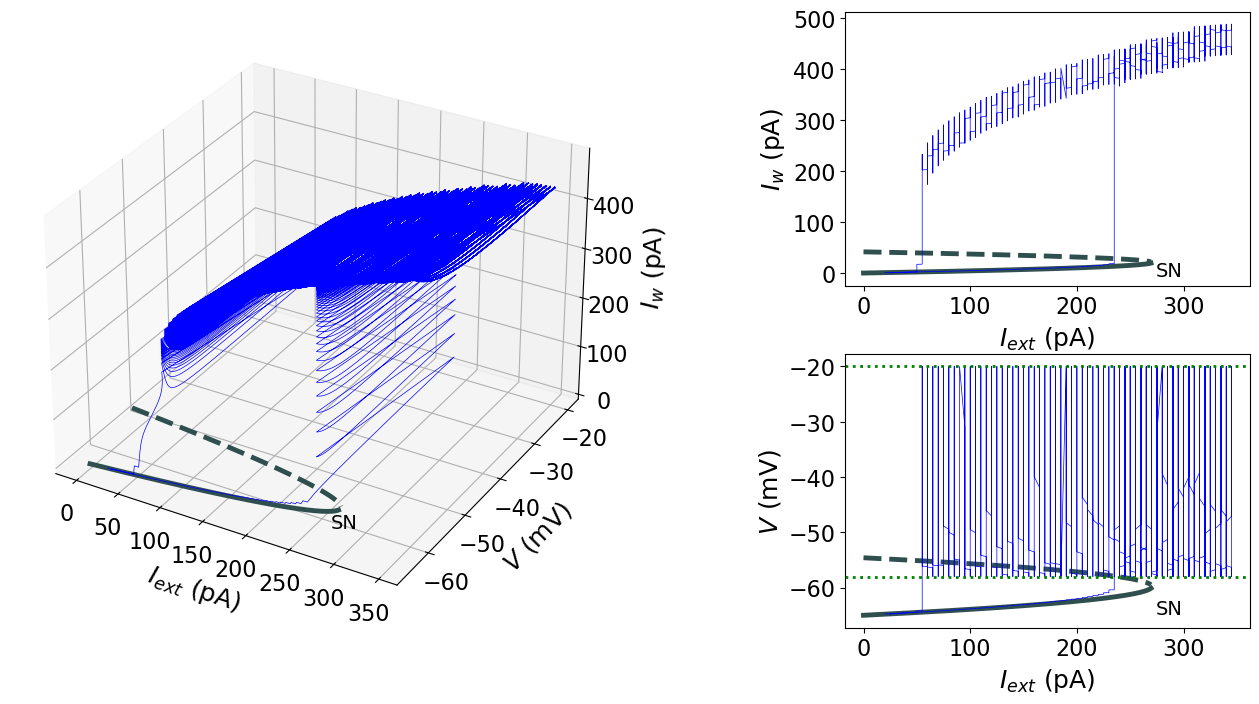

In [11]:
# Create a figure with 3 subplots (2 columns), with the first column spanning the 3D plot
fig = plt.figure(figsize=(16, 8))
gs = fig.add_gridspec(2, 2, width_ratios=[1.8, 1.2],
                            wspace=0.45,   # horizontal spacing between columns
                            hspace=0.25    # vertical spacing between rows
)

# 3D plot (left column, first row)
ax3d = fig.add_subplot(gs[:, 0], projection='3d')

# Plot root 1
ax3d.plot(I_ext_values, roots1, wr1, lw=3.5, color='darkslategrey', label='Root 1')
# Plot root 2
ax3d.plot(I_ext_values, roots2, wr2, lw=3.5, color='darkslategrey', linestyle='--', label='Root 2')
# Plot trajectory from simulation
ax3d.plot(current_array, VarV, Varw, color='blue', linestyle='-', lw=.5)

ax3d.set_xlabel('$I_{ext}$ (pA)', labelpad=10)
ax3d.set_ylabel('$V$ (mV)', labelpad=10)
ax3d.set_zlabel('$I_w$ (pA)', labelpad=10)

ax3d.text2D(0.55, .15, 'SN', transform=ax3d.transAxes, ha='center', va='bottom', fontsize=14)
#ax3d.legend()

# 2D plot 1 (right column, first row)
ax2d1 = fig.add_subplot(gs[0, 1])

ax2d1.plot(I_ext_values, wr1,lw=3.5, c='darkslategrey', label='Root 1')
ax2d1.plot(I_ext_values, wr2, lw=3.5, ls='--', c='darkslategrey', label='Root 2')
ax2d1.plot(current_array, Varw, color='blue', linestyle='-', lw=.5)

ax2d1.set_xlabel('$I_{ext}$ (pA)')
ax2d1.set_ylabel('$I_w$ (pA)')
ax2d1.text(0.8, .02, 'SN', transform=ax2d1.transAxes, ha='center', va='bottom', fontsize=14)
#ax2d1.legend()

# 2D plot 2 (right column, second row)
ax2d2 = fig.add_subplot(gs[1, 1])

ax2d2.plot(I_ext_values, roots1, lw=3.5, c='darkslategrey', label='Root 1')
ax2d2.plot(I_ext_values, roots2, lw=3.5, ls='--', c='darkslategrey', label='Root 2')
ax2d2.plot(current_array, VarV, color='blue', linestyle='-', lw=.5)
ax2d2.axhline(y=V_reset, lw=2, color='g', linestyle='dotted')
ax2d2.axhline(y=V_spike, lw=2, color='g', linestyle='dotted')

ax2d2.set_xlabel('$I_{ext}$ (pA)')
ax2d2.set_ylabel('$V$ (mV)')
ax2d2.text(0.8, .035, 'SN', transform=ax2d2.transAxes, ha='center', va='bottom', fontsize=14)
#ax2d2.legend()

plt.show()